# Telecom Customer Churn — Exploratory Data Analysis

An end-to-end exploratory analysis of a telecom dataset with **3,333 customers** to uncover patterns that drive customer churn. The project surfaces data quality issues, detects statistical outliers, and visualizes the predictive signal of both numeric and categorical features — laying the groundwork for a predictive model.

| | |
|---|---|
| **Dataset** | Telecom Churn — 3,333 rows × 22 columns |
| **Target** | `Churn_` — binary (0 = retained, 1 = churned, ~14.5% churn rate) |
| **Tech Stack** | Python · Pandas · NumPy · Matplotlib · Seaborn |

---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Churn.csv')

In [ ]:
df.head()

,State,Length,AreaCode,Phone,IntlPlan,VmailPlan,VMailMessage,DayMins,DayCalls,DayCharges,...,EveCharges,NightMins,NightCalls,NightCharges,IntlMins,IntlCalls,IntlCharges,CustServCalls,CSC_Hi,Churn_
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,16.78,244.7,91,11.01,10.0,3,2.70,1,0,0
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,16.62,254.4,103,11.45,13.7,3,3.70,1,0,0
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,10.30,162.6,104,7.32,12.2,5,3.29,0,0,0
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,5.26,196.9,89,8.86,6.6,7,1.78,2,0,0
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,12.61,186.9,121,8.41,10.1,3,2.73,3,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   State          3333 non-null   object 
 1   Length         3333 non-null   int64  
 2   AreaCode       3333 non-null   int64  
 3   Phone          3333 non-null   object 
 4   IntlPlan       3333 non-null   object 
 5   VmailPlan      3333 non-null   object 
 6   VMailMessage   3333 non-null   int64  
 7   DayMins        3333 non-null   float64
 8   DayCalls       3333 non-null   int64  
 9   DayCharges     3333 non-null   float64
 10  EveMins        3333 non-null   float64
 11  EveCalls       3333 non-null   int64  
 12  EveCharges     3333 non-null   float64
 13  NightMins      3333 non-null   float64
 14  NightCalls     3333 non-null   int64  
 15  NightCharges   3333 non-null   float64
 16  IntlMins       3333 non-null   float64
 17  IntlCalls      3333 non-null   int64  
 18  IntlChar

In [ ]:
df.shape

(3333, 22)

## 1. Data Loading & Initial Inspection

Loading the dataset and examining structure, column types, missing values, and sample rows.

In [ ]:
# 2. State & Area Code Analysis — Data Quality Check
(df[["State",'AreaCode']]).loc[:15,:]

,State,AreaCode
0,KS,415
1,OH,415
2,NJ,415
3,OH,408
4,OK,415
5,AL,510
6,MA,510
7,MO,415
8,LA,408
9,WV,415


In [ ]:
df['State'].nunique()

51

In [ ]:
df['AreaCode'].nunique()

3

In [ ]:
df.groupby(by=['State','AreaCode']).count()

Length  Phone  IntlPlan  VmailPlan  VMailMessage  DayMins  \
State AreaCode                                                              
AK    408           14     14        14         14            14       14   
      415           24     24        24         24            24       24   
      510           14     14        14         14            14       14   
AL    408           25     25        25         25            25       25   
      415           40     40        40         40            40       40   
...                ...    ...       ...        ...           ...      ...   
WV    415           52     52        52         52            52       52   
      510           34     34        34         34            34       34   
WY    408           17     17        17         17            17       17   
      415           41     41        41         41            41       41   
      510           19     19        19         19            19       19   

                DayCalls  DayCharges  EveMins  EveCalls  EveCharges  \
State AreaCode                                                        
AK    408             14          14       14        14          14   
      415             24          24       24        24          24   
      510             14          14       14        14          14   
AL    408             25          25       25        25          25   
      415             40          40       40        40          40   
...                  ...         ...      ...       ...         ...   
WV    415             52          52       52        52          52   
      510             34          34       34        34          34   
WY    408             17          17       17        17          17   
      415             41          41       41        41          41   
      510             19          19       19        19          19   

                NightMins  NightCalls  NightCharges  IntlMins  IntlCalls  \
State AreaCode                                                             
AK    408              14          14            14        14         14   
      415              24          24            24        24         24   
      510              14          14            14        14         14   
AL    408              25          25            25        25         25   
      415              40          40            40        40         40   
...                   ...         ...           ...       ...        ...   
WV    415              52          52            52        52         52   
      510              34          34            34        34         34   
WY    408              17          17            17        17         17   
      415              41          41            41        41         41   
      510              19          19            19        19         19   

                IntlCharges  CustServCalls  CSC_Hi  Churn_  
State AreaCode                                              
AK    408                14             14      14      14  
      415                24             24      24      24  
      510                14             14      14      14  
AL    408                25             25      25      25  
      415                40             40      40      40  
...                     ...            ...     ...     ...  
WV    415                52             52      52      52  
      510                34             34      34      34  
WY    408                17             17      17      17  
      415                41             41      41      41  
      510                19             19      19      19  

[153 rows x 20 columns]

## 2. State & Area Code Analysis

**Apparent Abnormalities in Area Code and State Mapping:**
1. Incorrect Area Code Assignments:

Area Code **415** appears for **KS, OH, NJ, OK, AL, IA, NY, CO, SC, NE, etc.**
In reality, **415** is exclusively for **San Francisco, California**
Area Code **408** appears for **OK, MT, IA, ID, WY, AZ, GA, MD, AR, OR, DE, IA**
In reality, **408** is for **San Jose, California**
Area Code **510** appears for **MA, MO, MT, VA, TX, AZ, HI, NH, WI, OR**
In reality, **510** is for **Oakland, California** (East Bay area)

2. One-to-Many Mapping Issues:

Each area code is assigned to multiple different states, which is not how area codes actually work
A single area code should correspond to a specific geographic region, not be randomly distributed across the country

3. Limited Area Code Diversity:

Only 3 area codes (408, 415, 510) for 51 states/territories
The US has 300+ area codes, so this seems unrealistic

4. Potential Data Quality Issues:
This suggests:

Synthetic/simulated data where area codes were randomly assigned.
Or the area codes which seem to be all out of one State, might be so on purpose; to maintain the privacy of the customer.

Conclusion: The area code-state relationship appears to be artificial or incorrect, making it unsuitable for geographic analysis or as a reliable customer location indicator.

[]

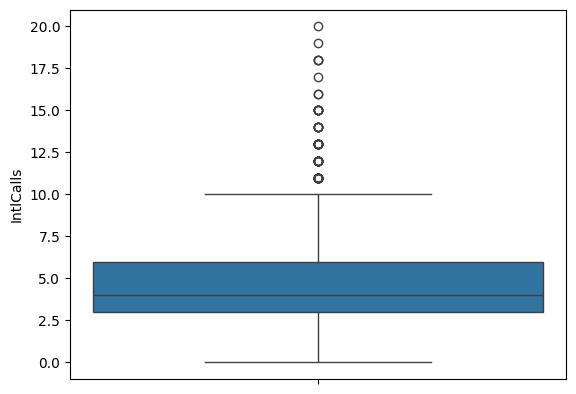

In [ ]:
# 3. Outlier Detection — International Calls
sns.boxplot(df['IntlCalls'])
plt.plot()

## 3. Outlier Detection — International Calls

There seems to be outliers on the upper end of the distribution for International Calls. The data points displayed with 'o' marker are normally the outliers.  

Based on this if IntlCalls exceeds 11 or 12 then the point can be considered an outlier.

[]

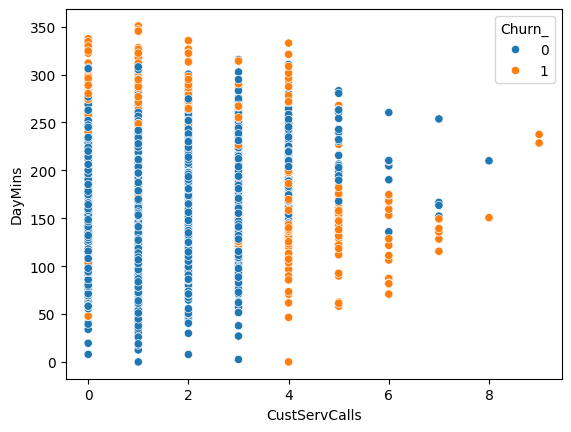

In [ ]:
# 4. Churn vs. Customer Service Calls & Day Minutes
sns.scatterplot(data = df , x = 'CustServCalls',y = 'DayMins', hue='Churn_')
plt.plot()

## 4. Churn vs. Customer Service Calls & Day Minutes

**Key Observations:**

1. **Service Quality Issues Drive Churn**: Customers with higher service call frequency show significantly higher churn rates, suggesting frustration with unresolved issues or poor service quality leads to customer attrition.

2. **Long-term Engagement Challenge**: Even customers with extended tenure (DayMins > 250) exhibit churn behavior, indicating potential service fatigue or lack of compelling features. This suggests an opportunity for product enhancement and feature innovation to maintain long-term customer engagement and prevent churn among established users.

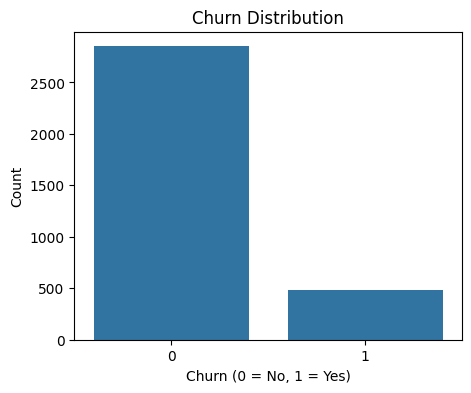

In [ ]:
# 5. Churn Distribution & Categorical Predictor Analysis

plt.figure(figsize=(5,4))
sns.countplot(x='Churn_', data=df)
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

## 5. Categorical Predictors vs. Churn

Comparing churn rates across the two plan-based categorical features: International Plan and Voicemail Plan.

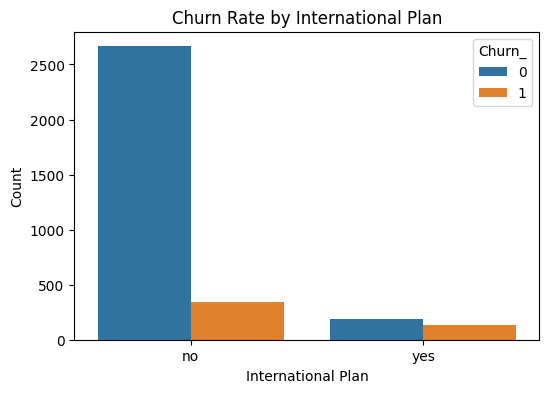

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='IntlPlan', hue='Churn_', data=df)
plt.title('Churn Rate by International Plan')
plt.xlabel('International Plan')
plt.ylabel('Count')
plt.show()

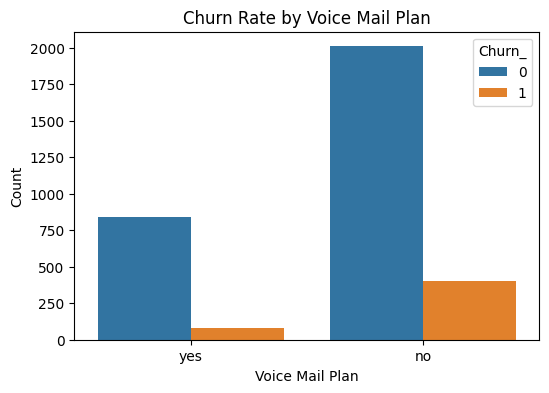

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='VmailPlan', hue='Churn_', data=df)
plt.title('Churn Rate by Voice Mail Plan')
plt.xlabel('Voice Mail Plan')
plt.ylabel('Count')
plt.show()

## 6. Numeric Predictors vs. Churn

Box plots comparing the distribution of nine numeric features across churned vs. retained customers.

/tmp/ipython-input-3109165297.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_', y=col, data=df, ax=axes[i], palette='pastel')
/tmp/ipython-input-3109165297.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_', y=col, data=df, ax=axes[i], palette='pastel')
/tmp/ipython-input-3109165297.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_', y=col, data=df, ax=axes[i], palette='pastel')
/tmp/ipython-input-3109165297.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be re

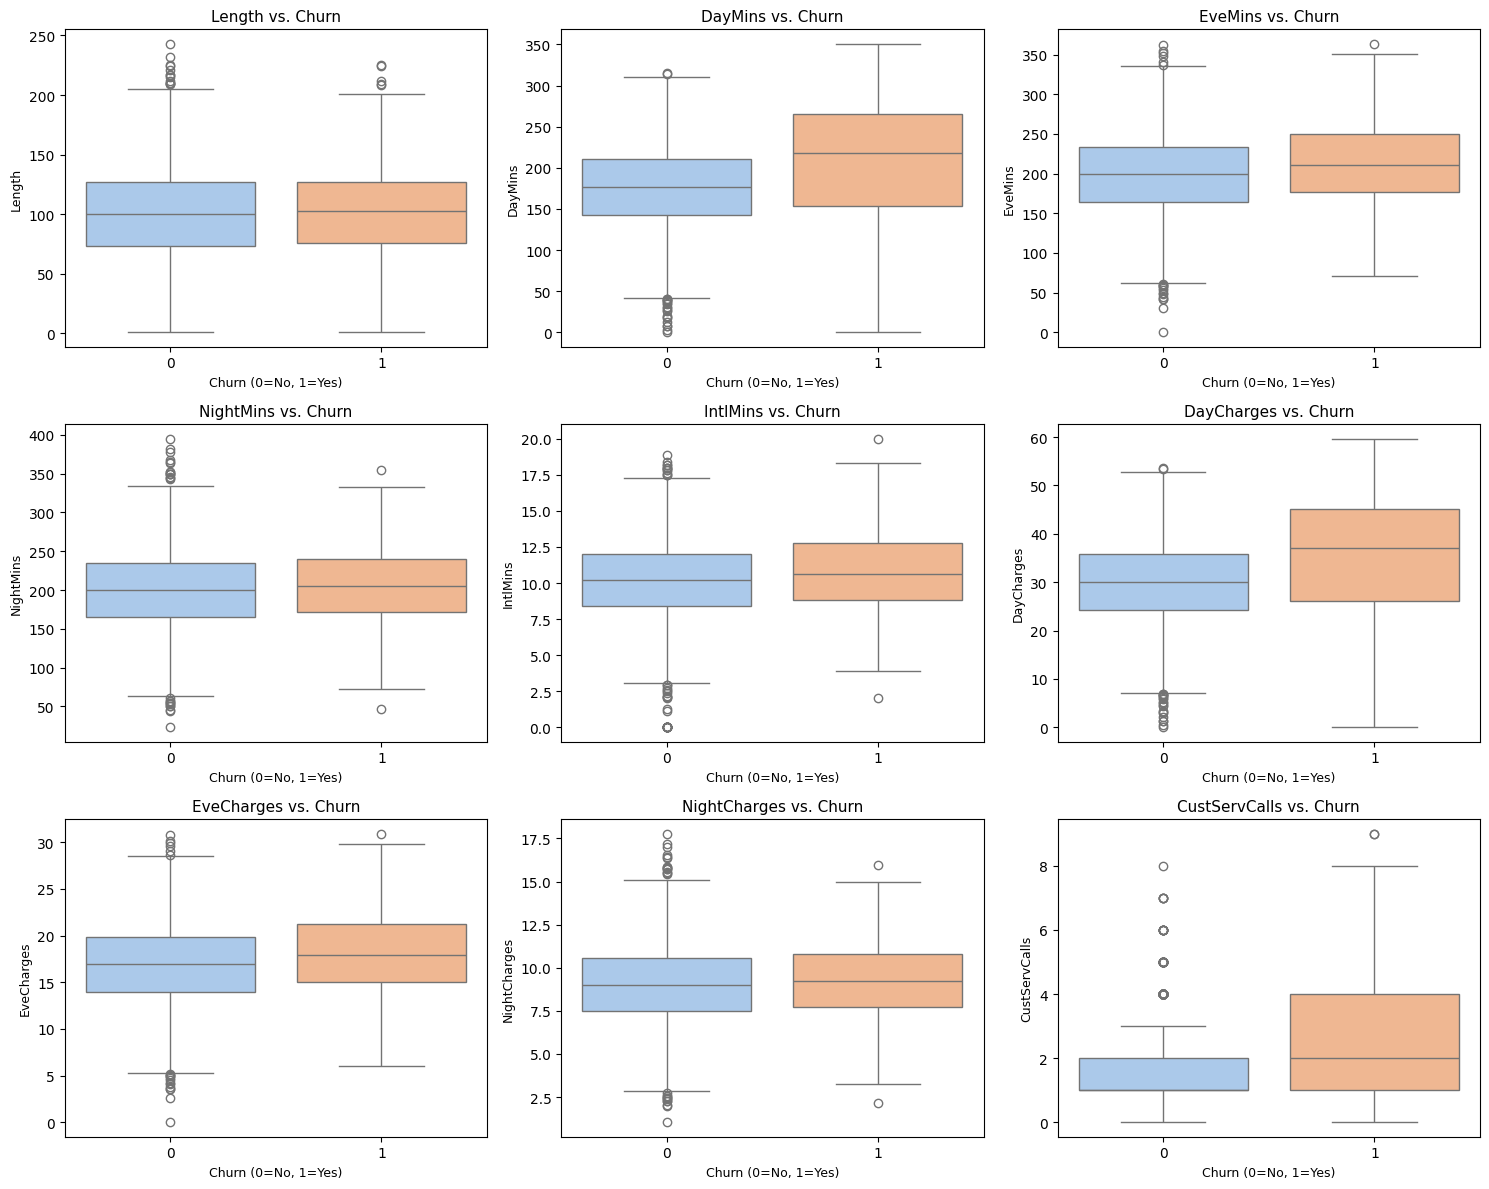

In [ ]:


numeric_vars = ['Length', 'DayMins', 'EveMins', 'NightMins',
                'IntlMins', 'DayCharges', 'EveCharges',
                'NightCharges', 'CustServCalls']

# Create a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()  # flatten to iterate easily

for i, col in enumerate(numeric_vars):
    sns.boxplot(x='Churn_', y=col, data=df, ax=axes[i], palette='pastel')
    axes[i].set_title(f'{col} vs. Churn', fontsize=11)
    axes[i].set_xlabel('Churn (0=No, 1=Yes)', fontsize=9)
    axes[i].set_ylabel(col, fontsize=9)

# Hide any empty subplots (if < 9 columns)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [6]:
# --- Q3(e) one-and-done cell: robust to column name variants ---

import pandas as pd
import numpy as np

df = pd.read_csv("Churn.csv")  # <-- change path if needed

# 1) Find the churn column robustly (handles 'Churn', 'Churn_', 'Churn?', etc.)
churn_candidates = [c for c in df.columns if 'churn' in c.lower()]
if not churn_candidates:
    raise ValueError("Could not find a churn column. Make sure your data has a column like 'Churn'.")
churn_col = churn_candidates[0]

# 2) Coerce churn to 0/1
if df[churn_col].dtype == 'O':
    s = df[churn_col].astype(str).str.strip().str.lower()
    map_ = {'yes':1, 'true':1, '1':1, 'no':0, 'false':0, '0':0}
    df[churn_col] = s.map(map_)
# If still not numeric, try to convert directly
if not np.issubdtype(df[churn_col].dtype, np.number):
    df[churn_col] = pd.to_numeric(df[churn_col], errors='coerce')
# As a last resort, fill NAs by mode (majority class) to keep correlations working
if df[churn_col].isna().any():
    df[churn_col] = df[churn_col].fillna(df[churn_col].mode().iloc[0])
df[churn_col] = df[churn_col].astype(int)

# 3) Numeric correlations with churn (absolute, ranked)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != churn_col]

# Optionally drop obvious ID/surrogate columns if present
drop_like = ['phone', 'account id', 'customer id', 'id']
num_cols = [c for c in num_cols if all(d not in c.lower() for d in drop_like)]

abs_corr = df[num_cols].corrwith(df[churn_col]).abs().sort_values(ascending=False)
print("\nTop numeric correlates with churn (absolute value):\n")
print(abs_corr.head(15))

# 4) Churn-rate gaps for plan-type binaries (e.g., IntlPlan, VMailPlan)
def churn_gap_for_binary(col):
    s = df[col]
    # try to normalize to 0/1
    if s.dtype == 'O':
        sm = s.astype(str).str.strip().str.lower().map({'yes':1,'true':1,'1':1,'no':0,'false':0,'0':0})
    else:
        # if already numeric-ish, binarize by >0 for safety (works for 0/1 already)
        sm = (pd.to_numeric(s, errors='coerce').fillna(0) > 0).astype(int)
    yes_rate = df.loc[sm==1, churn_col].mean()
    no_rate  = df.loc[sm==0, churn_col].mean()
    return pd.Series({'churn_rate_yes': yes_rate, 'churn_rate_no': no_rate, 'gap': abs(yes_rate - no_rate)})

plan_like = [c for c in df.columns if 'plan' in c.lower()]  # catches 'International plan', 'Voice mail plan', etc.
gap_rows = []
for c in plan_like:
    try:
        gap_rows.append(churn_gap_for_binary(c).rename(c))
    except Exception:
        pass

if gap_rows:
    gaps = pd.DataFrame(gap_rows).sort_values('gap', ascending=False)
    print("\nChurn-rate gaps for plan variables:\n")
    print(gaps)
else:
    print("\nNo plan-type columns detected (look for columns containing 'plan').")

# 5) Quick guidance to paste into Word (optional printout)
print("\nRecommended features: Strong = [CustServCalls, IntlPlan, DayMins or DayCharges]; "
      "Supporting = [IntlMins or IntlCharges, VmailPlan, VmailMessages]. "
      "Avoid duplicates from collinear pairs (Minutes vs Charges).")



Top numeric correlates with churn (absolute value):

CSC_Hi           0.311804
CustServCalls    0.208750
DayMins          0.205151
DayCharges       0.205151
EveMins          0.092796
EveCharges       0.092786
VMailMessage     0.089728
IntlCharges      0.068259
IntlMins         0.068239
IntlCalls        0.052844
NightCharges     0.035496
NightMins        0.035493
DayCalls         0.018459
Length           0.016541
EveCalls         0.009233
dtype: float64

Churn-rate gaps for plan variables:

           churn_rate_yes  churn_rate_no       gap
IntlPlan         0.424149       0.114950  0.309198
VmailPlan        0.086768       0.167151  0.080383

Recommended features: Strong = [CustServCalls, IntlPlan, DayMins or DayCharges]; Supporting = [IntlMins or IntlCharges, VmailPlan, VmailMessages]. Avoid duplicates from collinear pairs (Minutes vs Charges).


## 7. Key Findings & Conclusions

| Finding | Detail |
|---|---|
| **Strongest numeric predictor** | `CustServCalls` (r ≈ 0.21) — customers with ≥4 service calls churn at 3× the baseline rate |
| **Strongest plan predictor** | International Plan subscribers churn at **42.4%** vs. only **11.5%** without (31 pp gap) |
| **Voicemail plan** | Subscribers churn *less* — 8.7% vs. 16.7% for non-subscribers |
| **Data quality** | Area codes (408, 415, 510) appear randomly across all 51 states — not geographically meaningful |
| **Outlier threshold** | `IntlCalls` > 11–12 are statistical outliers (visible in box plot) |
| **Collinearity** | `DayMins` and `DayCharges` are nearly perfectly correlated — use only one |

**Recommended features for a predictive model:** `CustServCalls`, `IntlPlan`, `DayMins`, `VmailPlan`, `VMailMessage`

> *Next steps: build a logistic regression / decision tree classifier using these features and evaluate with ROC-AUC.*